THIS MOST OF THE ANALYSIS IS INCORRECT. I analyzed the max and min and failed to measure the movement between

In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import os

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [42]:
query_min = "SELECT * FROM gold.active_1min"
query_30 = "SELECT * FROM gold.active_30min"
query_hr = "SELECT * FROM gold.active_1hr"
query_day = "SELECT * FROM gold.active_daily"

In [43]:
df_min = pd.read_sql(query_min,engine)
df_30 = pd.read_sql(query_30,engine)
df_hr = pd.read_sql(query_hr,engine)
df_day = pd.read_sql(query_day,engine)

In [44]:
df_min.info()
df_30.info()
df_hr.info()
df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 126495 entries, 0 to 126494
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   contract  126495 non-null  str    
 1   bar_date  126495 non-null  object 
 2   bar_time  126495 non-null  object 
 3   high      126495 non-null  float64
 4   open      126495 non-null  float64
 5   close     126495 non-null  float64
 6   low       126495 non-null  float64
 7   volume    126495 non-null  float64
dtypes: float64(5), object(2), str(1)
memory usage: 7.7+ MB
<class 'pandas.DataFrame'>
RangeIndex: 4222 entries, 0 to 4221
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   contract        4222 non-null   str    
 1   bar_date        4222 non-null   object 
 2   bar_time        4222 non-null   object 
 3   high            4222 non-null   float64
 4   open            4222 non-null   float64
 5   close           4222 non-n

Daily Price Movement

In [13]:
df_day['price_movement']=df_day['high']-df_day['low']

In [14]:
print(df_day['price_movement'].describe())
print('Median: ',df_day['price_movement'].median())
print("Std Dev: ",df_day['price_movement'].std())
print("IQR:", df_day['price_movement'].quantile(0.75) - df_day['price_movement'].quantile(0.25))

count    239.000000
mean      31.833682
std       24.244754
min        5.750000
25%       18.000000
50%       24.750000
75%       37.375000
max      185.750000
Name: price_movement, dtype: float64
Median:  24.75
Std Dev:  24.244753946965034
IQR: 19.375


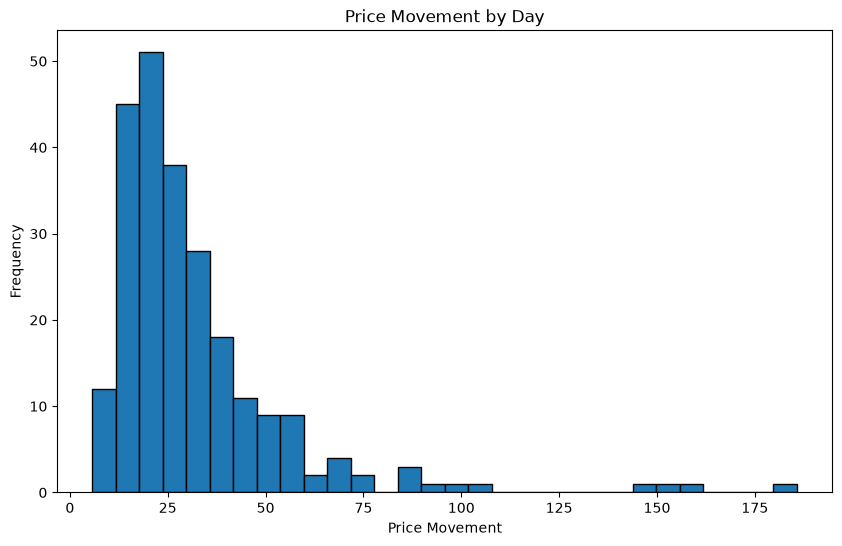

In [15]:
plt.figure(figsize=(10,6))
plt.hist(df_day['price_movement'],bins=30,edgecolor='black')
plt.xlabel('Price Movement')
plt.ylabel('Frequency')
plt.title('Price Movement by Day')
plt.show()

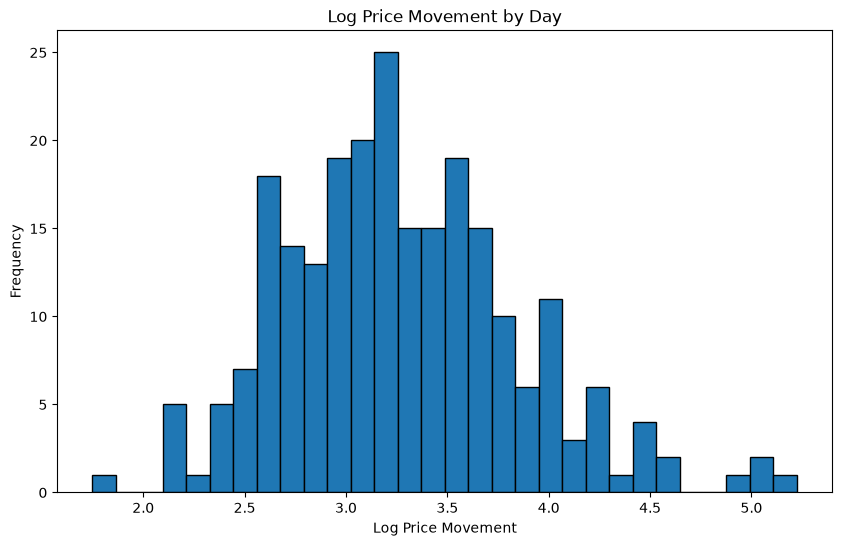

In [16]:
df_day['log_pm']=np.log(df_day['price_movement'])
plt.figure(figsize=(10,6))
plt.hist(df_day['log_pm'],bins=30,edgecolor='black')
plt.xlabel('Log Price Movement')
plt.ylabel('Frequency')
plt.title('Log Price Movement by Day')
plt.show()

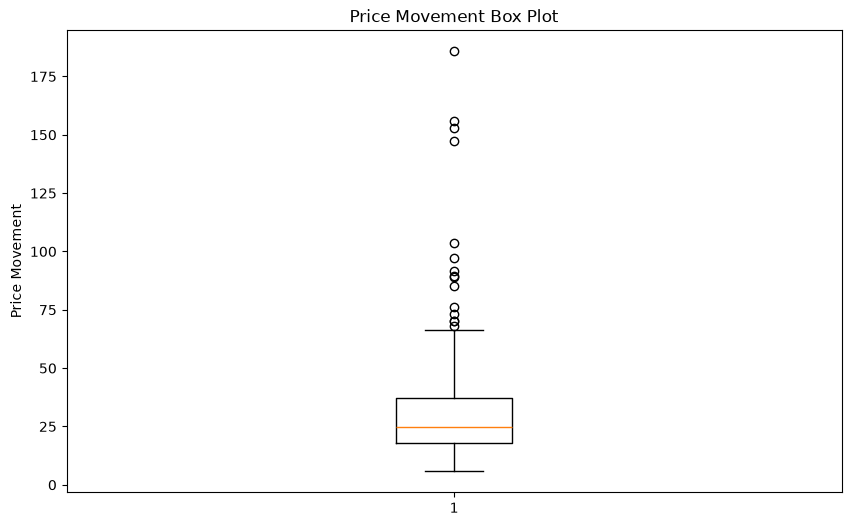

In [18]:
plt.figure(figsize=(10,6))
plt.boxplot(df_day['price_movement'])
plt.ylabel('Price Movement')
plt.title('Price Movement Box Plot')
plt.show()

In [ ]:
Hourly Price Movement

In [20]:
df_hr['price_movement']=df_hr['high']-df_hr['low']

In [21]:
print(df_hr['price_movement'].describe())
print('Median: ',df_hr['price_movement'].median())
print("Std Dev: ",df_hr['price_movement'].std())
print("IQR:", df_hr['price_movement'].quantile(0.75) - df_hr['price_movement'].quantile(0.25))

count    2347.000000
mean        9.403174
std         9.332106
min         0.250000
25%         4.500000
50%         7.250000
75%        11.250000
max       114.750000
Name: price_movement, dtype: float64
Median:  7.25
Std Dev:  9.33210625196275
IQR: 6.75


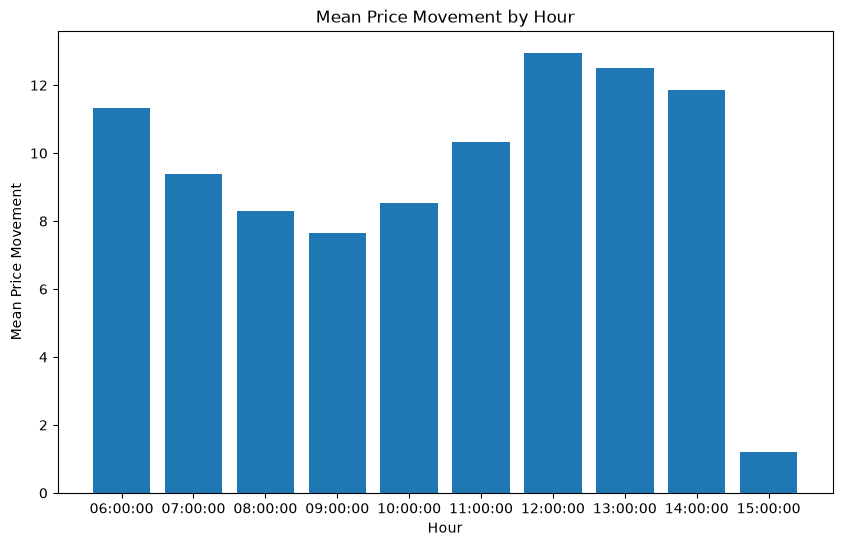

In [29]:
hr_agg = df_hr.groupby('bar_time')['price_movement'].agg(['mean', 'median', 'std'])
plt.figure(figsize=(10,6))
plt.bar(hr_agg.index.astype(str),hr_agg['mean'])
plt.xlabel('Hour')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movement by Hour')
plt.show()

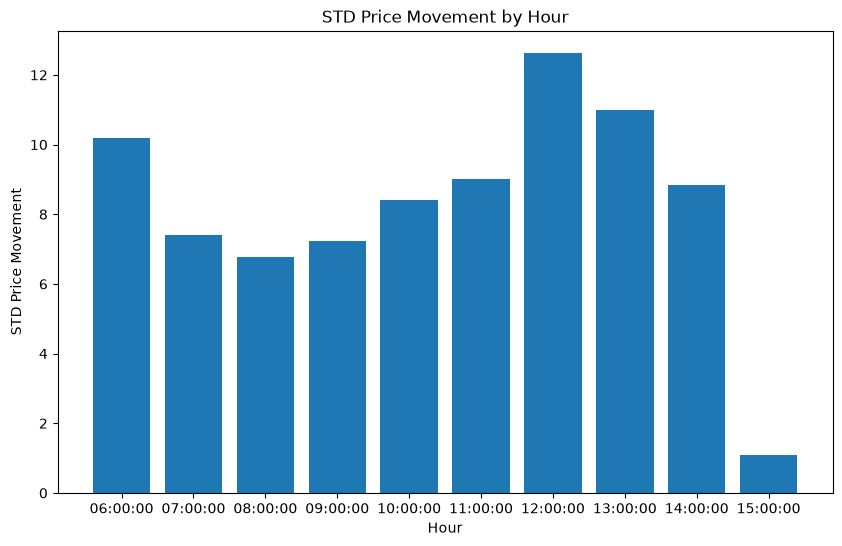

In [37]:
plt.figure(figsize=(10,6))
plt.bar(hr_agg.index.astype(str),hr_agg['std'])
plt.xlabel('Hour')
plt.ylabel('STD Price Movement')
plt.title('STD Price Movement by Hour')
plt.show()

30 Minute Analysis

In [45]:
df_30['price_movement']=df_30['high']-df_30['low']

In [46]:
print(df_30['price_movement'].describe())
print('Median: ',df_30['price_movement'].median())
print("Std Dev: ",df_30['price_movement'].std())
print("IQR:", df_30['price_movement'].quantile(0.75) - df_30['price_movement'].quantile(0.25))

count    4222.000000
mean        7.275580
std         6.732849
min         0.250000
25%         3.500000
50%         5.500000
75%         8.500000
max       114.750000
Name: price_movement, dtype: float64
Median:  5.5
Std Dev:  6.732849126690476
IQR: 5.0


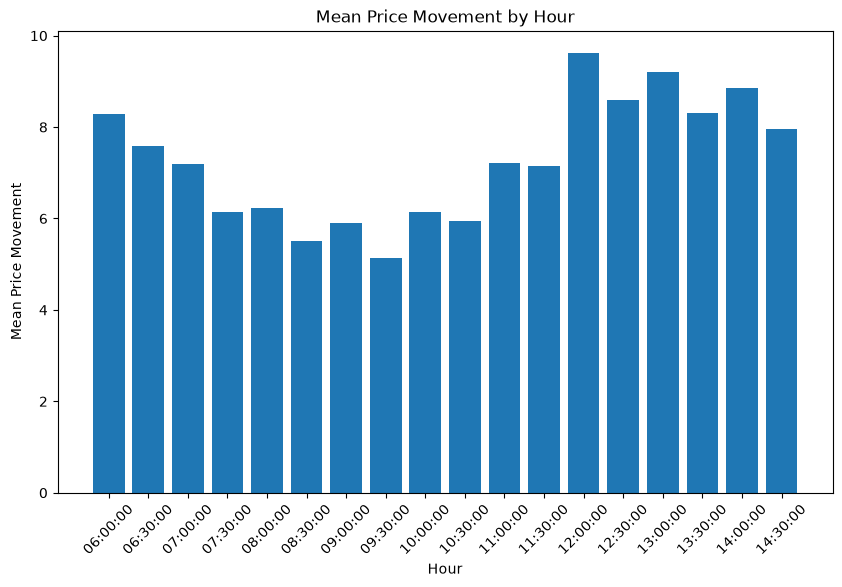

In [49]:
agg_30 = df_30.groupby('bar_time')['price_movement'].agg(['mean', 'median', 'std'])
plt.figure(figsize=(10,6))
plt.bar(agg_30.index.astype(str),agg_30['mean'])
plt.xlabel('Hour')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movement by Hour')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

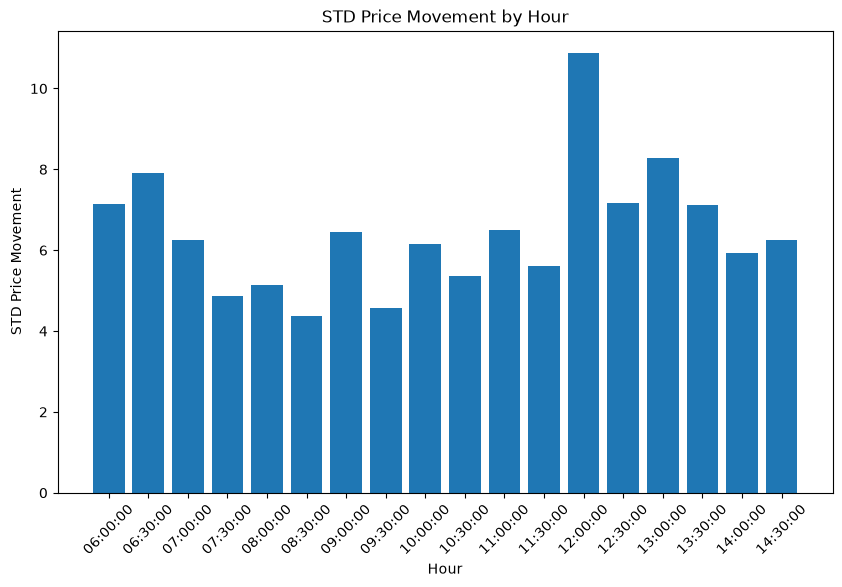

In [50]:
plt.figure(figsize=(10,6))
plt.bar(agg_30.index.astype(str),agg_30['std'])
plt.xlabel('Hour')
plt.ylabel('STD Price Movement')
plt.title('STD Price Movement by Hour')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

In [ ]:
Minute Analysis

In [33]:
df_min['price_movement']=df_min['high']-df_min['low']

In [34]:
print(df_min['price_movement'].describe())
print('Median: ',df_min['price_movement'].median())
print("Std Dev: ",df_min['price_movement'].std())
print("IQR:", df_min['price_movement'].quantile(0.75) - df_min['price_movement'].quantile(0.25))

count    126729.000000
mean          1.171920
std           1.289927
min           0.000000
25%           0.500000
50%           0.750000
75%           1.500000
max          94.250000
Name: price_movement, dtype: float64
Median:  0.75
Std Dev:  1.2899272321564388
IQR: 1.0


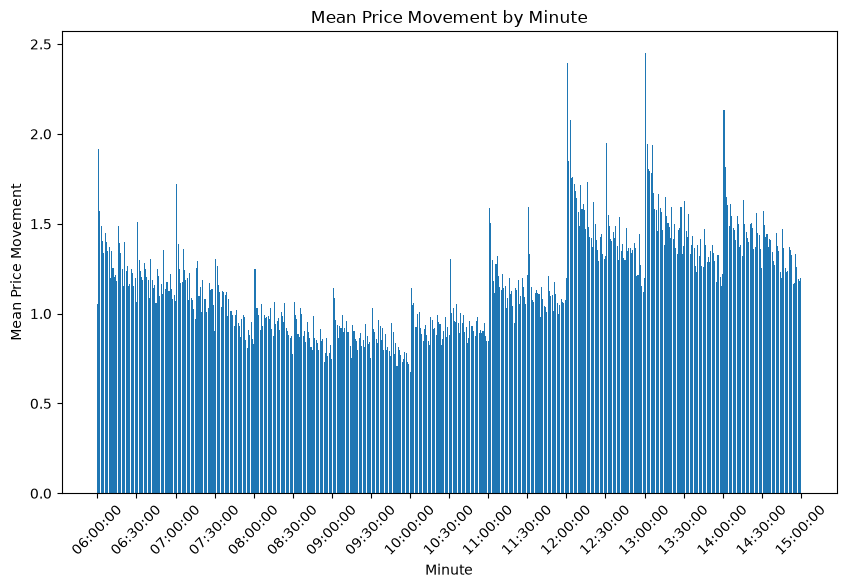

In [40]:
min_agg = df_min.groupby('bar_time')['price_movement'].agg(['mean', 'median', 'std'])
plt.figure(figsize=(10,6))
plt.bar(min_agg.index.astype(str),min_agg['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
plt.xlabel('Minute')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movement by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

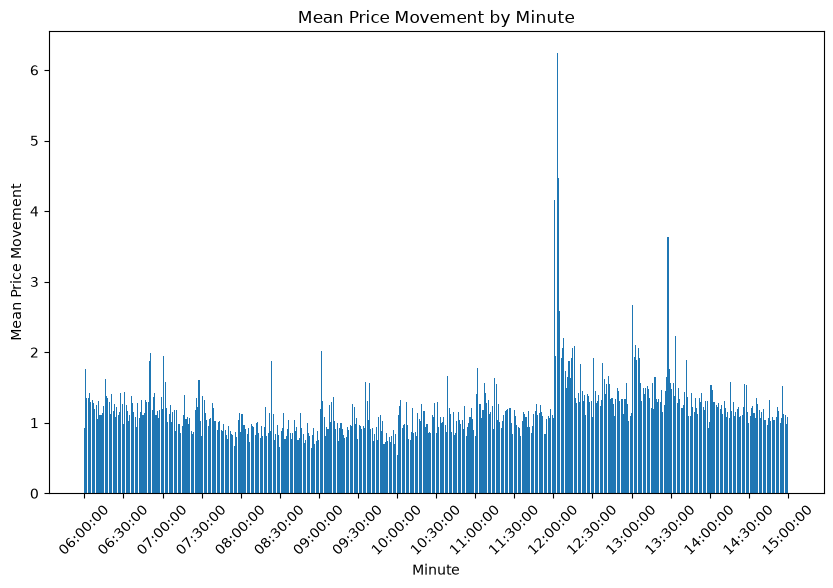

In [41]:
plt.figure(figsize=(10,6))
plt.bar(min_agg.index.astype(str),min_agg['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
plt.xlabel('Minute')
plt.ylabel('Mean Price Movement')
plt.title('Mean Price Movement by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()